# Reconhecimento de Padrões — Agrupamento

**Exercício:** (1) BSAS + segundo algoritmo de agrupamento, com seleção de $k$ via análise de derivada do $\tau$; (2) Propostas criativas de agrupamento via **Janelas de Parzen** e **KNN**.

**Datasets:** *Iris* e *Wine* (UCI / `sklearn`).

---

## Sumário
1. Bibliotecas e utilitários
2. Carregamento e pré-processamento dos dados
3. **Questão 1** — BSAS + Agrupamento Hierárquico (seleção de $k$ via derivada de $\tau$)
4. **Questão 2a** — Agrupamento via Janelas de Parzen (busca de picos em mapa de densidade)
5. **Questão 2b** — Agrupamento via KNN (densidade local + grafo de vizinhança mútua)
6. Avaliação qualitativa e comparação entre os métodos
7. Discussão crítica


## 1. Bibliotecas e utilitários

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist, squareform, cdist

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110


### Utilitários de avaliação

Como os algoritmos retornam rótulos arbitrários (e.g., cluster *0* não precisa coincidir com a classe *0*), usamos o **Hungarian matching** para permutar os rótulos preditos e obter a acurácia qualitativa máxima. Também reportamos **ARI** (Adjusted Rand Index) e **NMI** (Normalized Mutual Information), que independem da permutação.


In [2]:
def best_match_accuracy(y_true, y_pred):
    """Acuracia apos alinhamento otimo de rotulos (Hungarian)."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    row, col = linear_sum_assignment(w.max() - w)
    mapping = dict(zip(row, col))
    y_mapped = np.array([mapping[int(l)] for l in y_pred])
    acc = (y_mapped == y_true).mean()
    return acc, y_mapped

def report(y_true, y_pred, name=''):
    acc, y_mapped = best_match_accuracy(y_true, y_pred)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    print(f'[{name}]  k_pred = {len(np.unique(y_pred))}  '
          f'acc* = {acc:.3f}   ARI = {ari:.3f}   NMI = {nmi:.3f}')
    return acc, ari, nmi, y_mapped


## 2. Carregamento e pré-processamento dos dados

Tanto *Iris* quanto *Wine* têm atributos em **escalas muito diferentes** (p.ex., em Wine, *proline* está em centenas/milhares enquanto *ash* fica perto de 2). Algoritmos baseados em distância euclidiana — BSAS, hierárquico, Parzen com kernel isotrópico, KNN — são dominados pelos atributos de maior escala se aplicados aos dados brutos. Por isso fazemos **padronização z-score** ($\mu = 0$, $\sigma = 1$) em cada atributo.

Para **visualização** 2D, projetamos via **PCA**. O PCA é usado apenas para *mostrar* os resultados — o agrupamento é feito no espaço original padronizado (com todos os atributos).


In [3]:
def load_and_prep(loader, name):
    data = loader()
    X_raw = data.data
    y     = data.target
    feat  = data.feature_names
    X = StandardScaler().fit_transform(X_raw)           # agrupamento: espaco padronizado
    X2 = PCA(n_components=2, random_state=0).fit_transform(X)  # visualizacao
    print(f'{name}:  n={X.shape[0]}  d={X.shape[1]}  classes={len(np.unique(y))}')
    return X, X2, y, feat

X_iris, X2_iris, y_iris, feat_iris = load_and_prep(load_iris, 'Iris')
X_wine, X2_wine, y_wine, feat_wine = load_and_prep(load_wine, 'Wine')


Iris:  n=150  d=4  classes=3
Wine:  n=178  d=13  classes=3


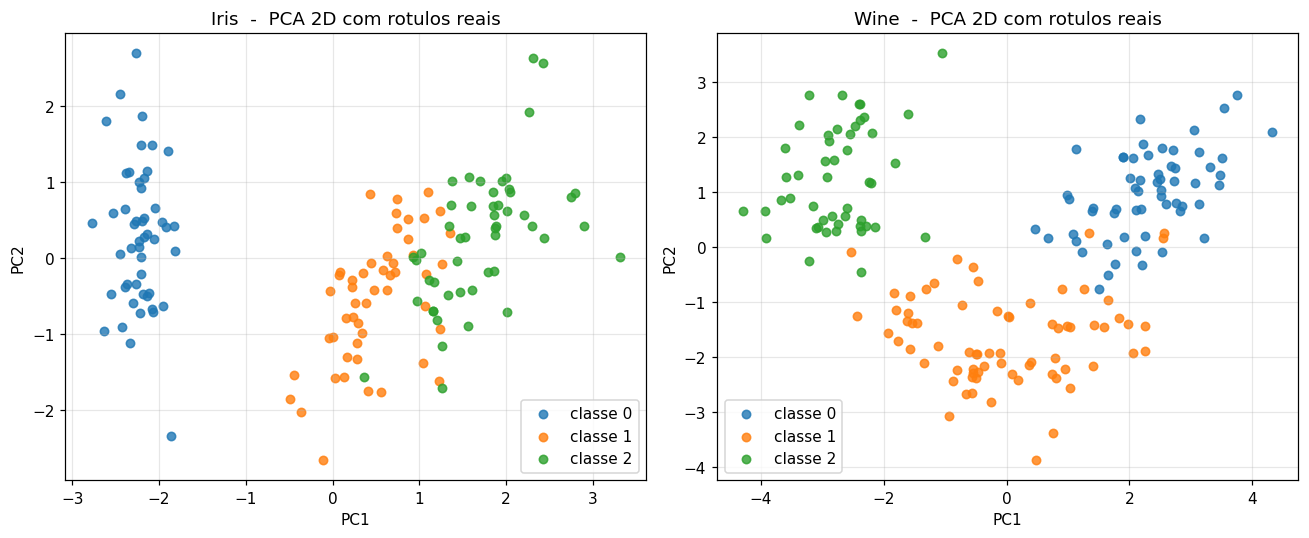

In [4]:
# Visualizacao dos dados (projecao PCA) com rotulos reais
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X2, y, name in [(axes[0], X2_iris, y_iris, 'Iris'),
                        (axes[1], X2_wine, y_wine, 'Wine')]:
    for c in np.unique(y):
        pos = y == c
        ax.scatter(X2[pos, 0], X2[pos, 1], s=30, alpha=0.8, label=f'classe {c}')
    ax.set_title(f'{name}  -  PCA 2D com rotulos reais')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


## 3. Questão 1 — BSAS + Agrupamento Hierárquico

### 3.1 Ideia
- O **BSAS** (Basic Sequential Algorithmic Scheme) é sensível a dois parâmetros: $\tau$ (limiar de dissimilaridade) e $q$ (nº máximo de clusters permitidos).
- Para $\tau$ muito pequeno, quase todo ponto vira um cluster próprio ($c \to m$). Para $\tau$ muito grande, tudo colapsa em um único cluster ($c = 1$).
- **Entre os extremos** costuma existir um **patamar** onde $c$ permanece aproximadamente constante — esse valor é uma boa estimativa de $k$ para o conjunto.
- Detectamos esse patamar numericamente: percorremos $\tau \in [\tau_{\min}, \tau_{\max}]$, contamos $c(\tau)$ e calculamos a **derivada discreta** $|\Delta c / \Delta \tau|$. O **maior intervalo contíguo de derivada nula** fornece o $k$ estimado.
- Com $k$ estimado, aplicamos **Agglomerative Clustering** (Ward) — que é menos sensível à ordem de apresentação que o próprio BSAS — para o particionamento final.


In [5]:
def BSAS(X, tau, max_clusters):
    """BSAS classico: atribui cada ponto ao cluster mais proximo ou cria novo
    se a distancia ao representante mais proximo exceder tau."""
    m = X.shape[0]
    ind = -np.ones(m, dtype=int)
    mus = [X[0].copy()]           # representantes (medias incrementais)
    sizes = [1]
    ind[0] = 0
    c = 0
    for i in range(1, m):
        d = np.array([np.linalg.norm(X[i] - mu) for mu in mus])
        k = int(np.argmin(d))
        if d[k] > tau and (c + 1) < max_clusters:
            c += 1
            mus.append(X[i].copy())
            sizes.append(1)
            ind[i] = c
        else:
            sizes[k] += 1
            mus[k] = mus[k] + (X[i] - mus[k]) / sizes[k]  # media incremental
            ind[i] = k
    return ind

def min_max_pairwise(X):
    D = squareform(pdist(X))
    Dnz = D + np.eye(D.shape[0]) * D.max()   # ignora diagonal
    return Dnz.min(), D.max()

def tau_sweep(X, n_taus=60, n_reps=10, max_clusters=None):
    """Varre tau; para cada tau, repete o BSAS com ordenacoes aleatorias e toma a mediana."""
    if max_clusters is None:
        max_clusters = X.shape[0]
    tau_min, tau_max = min_max_pairwise(X)
    taus = np.linspace(tau_min, tau_max, n_taus)
    counts = np.zeros(n_taus)
    for t_i, tau in enumerate(taus):
        vec = []
        for _ in range(n_reps):
            perm = np.random.permutation(X.shape[0])
            ind  = BSAS(X[perm], tau, max_clusters)
            vec.append(len(np.unique(ind)))
        counts[t_i] = np.median(vec)
    return taus, counts

def estimate_k_from_plateau(taus, counts, min_len=3):
    """Estima k como o valor do maior patamar contiguo em que c(tau) e constante,
    ignorando o patamar trivial c = 1 e patamares inferiores ao minimo de comprimento.
    Equivale a buscar a regiao de derivada nula mais extensa no grafico c(tau)."""
    dc = np.abs(np.diff(counts))
    segments = []
    i = 0
    n = len(counts)
    while i < n:
        j = i
        while j + 1 < n and counts[j + 1] == counts[i]:
            j += 1
        segments.append((i, j, int(counts[i]), j - i + 1))
        i = j + 1
    cand = [s for s in segments if s[2] >= 2 and s[3] >= min_len]
    if not cand:
        cand = [s for s in segments if s[2] >= 2]
        if not cand:
            return int(counts.max()), segments, dc
    cand.sort(key=lambda s: (-s[3], s[2]))
    best = cand[0]
    return best[2], segments, dc



=== Questao 1 - Iris ===
k estimado pelo patamar do BSAS: 2


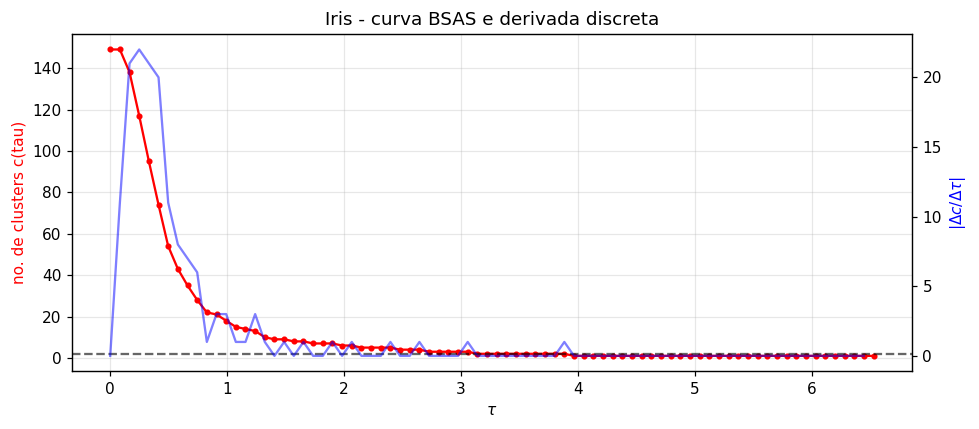

[BSAS->Ward  Iris]  k_pred = 2  acc* = 0.660   ARI = 0.544   NMI = 0.692

=== Questao 1 - Wine ===
k estimado pelo patamar do BSAS: 3


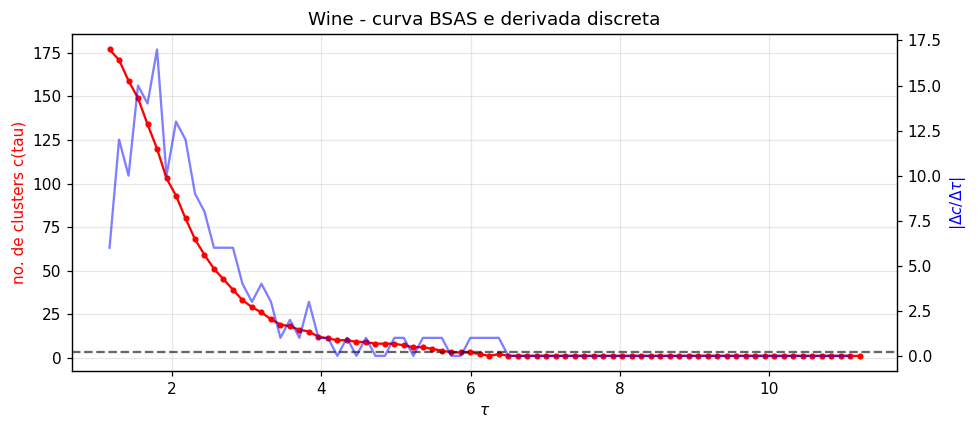

[BSAS->Ward  Wine]  k_pred = 3  acc* = 0.927   ARI = 0.790   NMI = 0.786


In [6]:
def plot_bsas_curve(taus, counts, dc, k_hat, name):
    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.plot(taus, counts, 'r-o', markersize=3, label='mediana de c(tau)')
    ax1.axhline(k_hat, ls='--', color='k', alpha=.6, label=f'k_hat = {k_hat}')
    ax1.set_xlabel(r'$\tau$'); ax1.set_ylabel('no. de clusters c(tau)', color='r')
    ax1.grid(alpha=.3)
    ax2 = ax1.twinx()
    ax2.plot(taus[:-1], dc, 'b-', alpha=.5, label=r'$|\Delta c/\Delta \tau|$')
    ax2.set_ylabel(r'$|\Delta c/\Delta \tau|$', color='b')
    ax1.set_title(f'{name} - curva BSAS e derivada discreta')
    fig.tight_layout(); plt.show()

def pipeline_q1(X, y, X2, name):
    print(f'\n=== Questao 1 - {name} ===')
    taus, counts = tau_sweep(X, n_taus=80, n_reps=15)
    k_hat, segs, dc = estimate_k_from_plateau(taus, counts, min_len=3)
    print(f'k estimado pelo patamar do BSAS: {k_hat}')
    plot_bsas_curve(taus, counts, dc, k_hat, name)
    agg = AgglomerativeClustering(n_clusters=k_hat, linkage='ward')
    y_hat = agg.fit_predict(X)
    report(y, y_hat, f'BSAS->Ward  {name}')
    return k_hat, y_hat

k_iris, yhat_iris_q1 = pipeline_q1(X_iris, y_iris, X2_iris, 'Iris')
k_wine, yhat_wine_q1 = pipeline_q1(X_wine, y_wine, X2_wine, 'Wine')


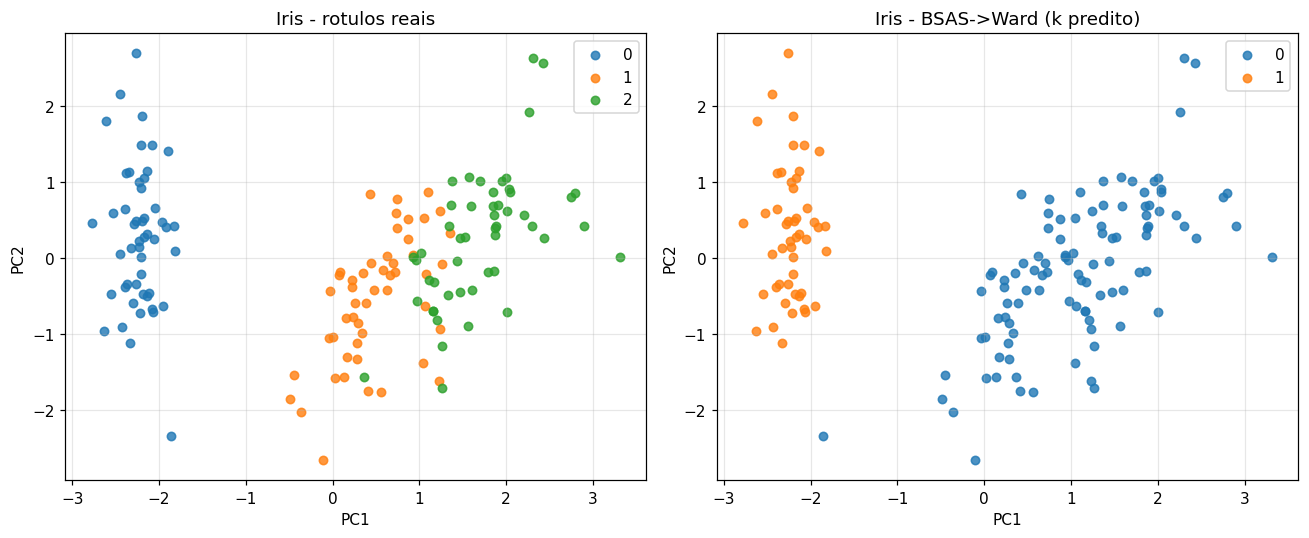

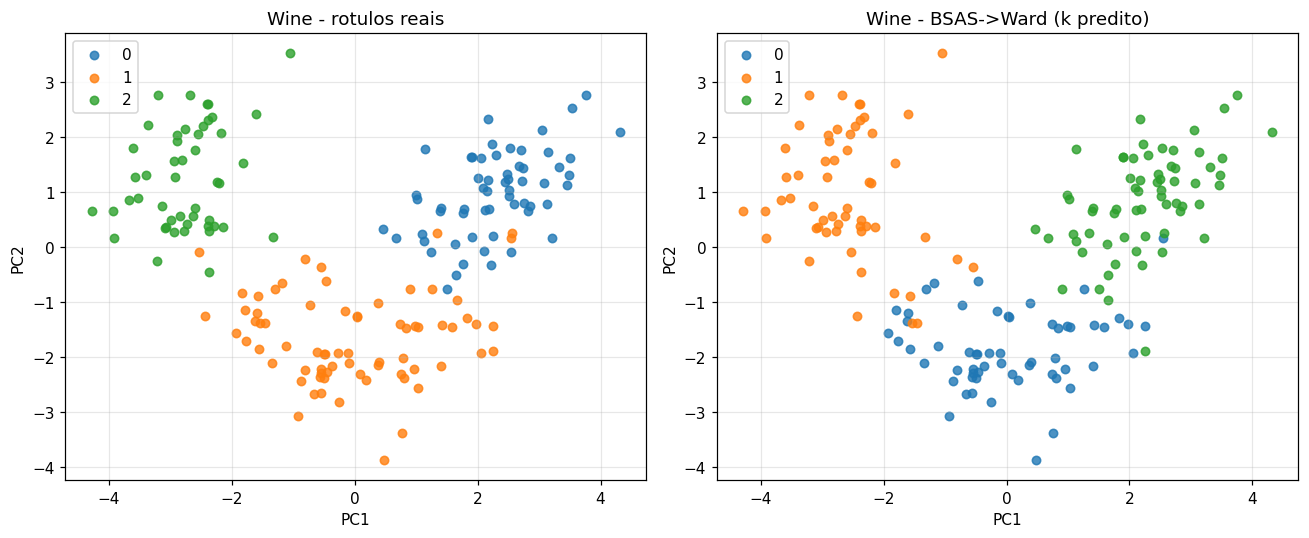

In [7]:
# Visualizacao dos agrupamentos obtidos na Questao 1
def plot_clusters_side(X2, y_true, y_pred, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, y, title in [(axes[0], y_true, f'{name} - rotulos reais'),
                         (axes[1], y_pred, f'{name} - BSAS->Ward (k predito)')]:
        for c in np.unique(y):
            pos = y == c
            ax.scatter(X2[pos, 0], X2[pos, 1], s=30, alpha=0.8, label=f'{c}')
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
        ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

plot_clusters_side(X2_iris, y_iris, yhat_iris_q1, 'Iris')
plot_clusters_side(X2_wine, y_wine, yhat_wine_q1, 'Wine')


## 4. Questão 2a — Agrupamento via Janelas de Parzen

### 4.1 Ideia
A ideia do curso: estimar a densidade $\hat p(x)$ como soma de **kernels gaussianos** centrados nos pontos, cada um com largura $h$:

$$\hat p(x) \;=\; \frac{1}{m\, h^n} \sum_{i=1}^{m} \varphi\!\left(\frac{x - x_i}{h}\right), \qquad \varphi(z) = \frac{1}{(2\pi)^{n/2}} \exp\!\left(-\tfrac{1}{2}\,z^\top z\right).$$

**Proposta criativa:** localizar **picos** (modas) em $\hat p$ — cada moda define um cluster. Em vez de varrer uma grade $n$-dimensional (caro em dimensões altas), fazemos **mode-seeking** pelo gradiente local: a partir de cada ponto $x_i$, subimos na densidade via **mean-shift** usando o próprio kernel gaussiano até convergir. Pontos que convergem para a mesma moda (dentro de uma tolerância) pertencem ao mesmo cluster.

Esse procedimento é uma implementação *mode-seeking* clássica equivalente a Parzen + *hill-climbing*, particionando o espaço pelas bacias de atração das modas de $\hat p$.

### 4.2 Escolha de $h$
A largura $h$ controla o **trade-off viés-variância**: $h$ pequeno → muitas modas espúrias; $h$ grande → modas reais coalescem. Como heurística inicial usamos a **regra de Silverman** em dimensão $n$:

$$h \;\approx\; \sigma \left(\frac{4}{(n+2)\,m}\right)^{1/(n+4)},$$

depois varremos alguns múltiplos $\alpha \cdot h$ para estudar a sensibilidade.


In [8]:
def parzen_density(X, query, h):
    """Densidade estimada por Parzen (kernel gaussiano isotropico) em query."""
    m, n = X.shape
    diff = (query[:, None, :] - X[None, :, :]) / h
    sqn  = np.sum(diff * diff, axis=2)
    norm = (2 * np.pi) ** (n / 2)
    return np.sum(np.exp(-0.5 * sqn), axis=1) / (m * (h ** n) * norm)

def silverman_h(X):
    m, n = X.shape
    sigma = np.mean(np.std(X, axis=0))
    return sigma * (4.0 / ((n + 2) * m)) ** (1.0 / (n + 4))

def mean_shift_parzen(X, h, max_iter=300, tol=1e-4, merge_tol=None):
    """Mean-shift com kernel gaussiano (bandwidth h). Retorna (labels, modes)."""
    m, n = X.shape
    if merge_tol is None:
        merge_tol = 0.5 * h
    points = X.copy()
    for _ in range(max_iter):
        diff = (points[:, None, :] - X[None, :, :]) / h
        w = np.exp(-0.5 * np.sum(diff * diff, axis=2))
        w_sum = w.sum(axis=1, keepdims=True) + 1e-12
        new_points = (w @ X) / w_sum
        shift = np.linalg.norm(new_points - points, axis=1).max()
        points = new_points
        if shift < tol:
            break
    modes = []
    labels = -np.ones(m, dtype=int)
    for i in range(m):
        assigned = False
        for mi, mode in enumerate(modes):
            if np.linalg.norm(points[i] - mode) < merge_tol:
                labels[i] = mi
                modes[mi] = (mode + points[i]) / 2
                assigned = True
                break
        if not assigned:
            modes.append(points[i].copy())
            labels[i] = len(modes) - 1
    return labels, np.array(modes)


In [9]:
def pipeline_parzen(X, y, X2, name, alphas=(0.6, 0.8, 1.0, 1.3, 1.6, 2.0)):
    print(f'\n=== Questao 2a - Parzen / mode-seeking - {name} ===')
    h0 = silverman_h(X)
    print(f'Silverman h0 = {h0:.3f}')
    results = []
    for a in alphas:
        h = a * h0
        lab, modes = mean_shift_parzen(X, h)
        k = len(np.unique(lab))
        acc, _ = best_match_accuracy(y, lab)
        ari = adjusted_rand_score(y, lab)
        results.append((a, h, k, acc, ari, lab))
        print(f'  alpha={a:4.2f}  h={h:6.3f}  k={k:3d}  acc*={acc:.3f}  ARI={ari:.3f}')
    best = max(results, key=lambda r: r[4])
    a, h, k, acc, ari, lab = best
    print(f'  -> melhor ARI em alpha={a}, h={h:.3f} com k={k}')
    report(y, lab, f'Parzen-MS  {name}')
    return lab, h, results

lab_parz_iris, h_iris, res_iris = pipeline_parzen(X_iris, y_iris, X2_iris, 'Iris')
lab_parz_wine, h_wine, res_wine = pipeline_parzen(X_wine, y_wine, X2_wine, 'Wine')



=== Questao 2a - Parzen / mode-seeking - Iris ===
Silverman h0 = 0.508
  alpha=0.60  h= 0.305  k= 10  acc*=0.693  ARI=0.513
  alpha=0.80  h= 0.407  k=  4  acc*=0.673  ARI=0.554
  alpha=1.00  h= 0.508  k=  3  acc*=0.680  ARI=0.564
  alpha=1.30  h= 0.661  k=  2  acc*=0.667  ARI=0.568
  alpha=1.60  h= 0.813  k=  2  acc*=0.667  ARI=0.568
  alpha=2.00  h= 1.016  k=  2  acc*=0.667  ARI=0.568
  -> melhor ARI em alpha=1.3, h=0.661 com k=2
[Parzen-MS  Iris]  k_pred = 2  acc* = 0.667   ARI = 0.568   NMI = 0.734

=== Questao 2a - Parzen / mode-seeking - Wine ===
Silverman h0 = 0.682
  alpha=0.60  h= 0.409  k=178  acc*=0.017  ARI=0.000
  alpha=0.80  h= 0.546  k=178  acc*=0.017  ARI=0.000
  alpha=1.00  h= 0.682  k=114  acc*=0.169  ARI=0.057
  alpha=1.30  h= 0.887  k= 30  acc*=0.826  ARI=0.715
  alpha=1.60  h= 1.091  k= 12  acc*=0.899  ARI=0.781
  alpha=2.00  h= 1.364  k=  4  acc*=0.916  ARI=0.761
  -> melhor ARI em alpha=1.6, h=1.091 com k=12
[Parzen-MS  Wine]  k_pred = 12  acc* = 0.899   ARI = 0.

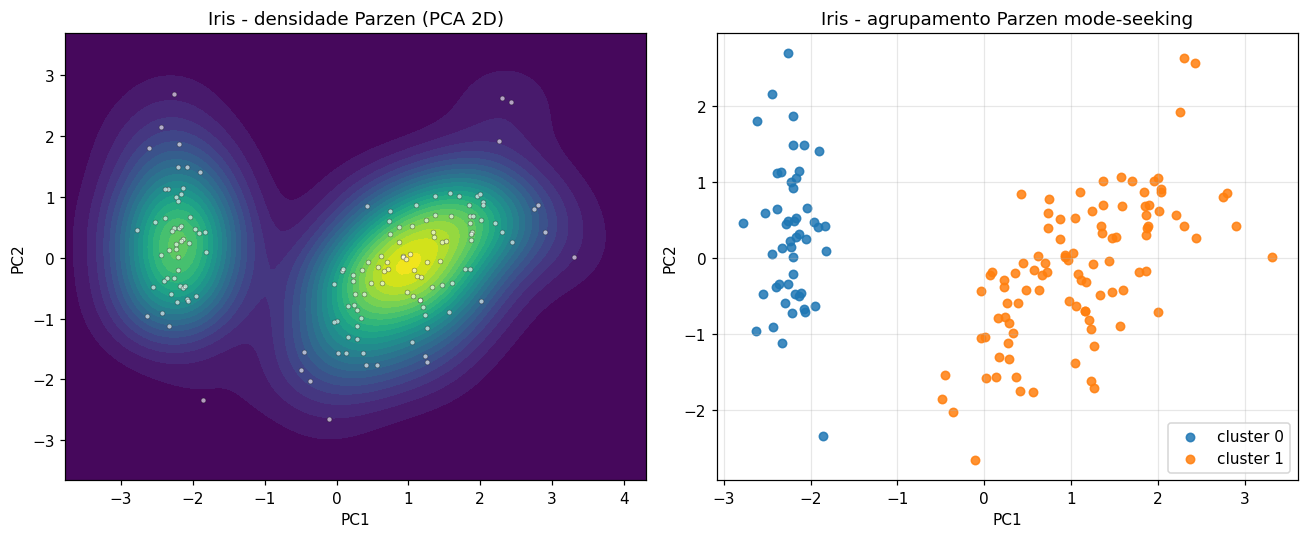

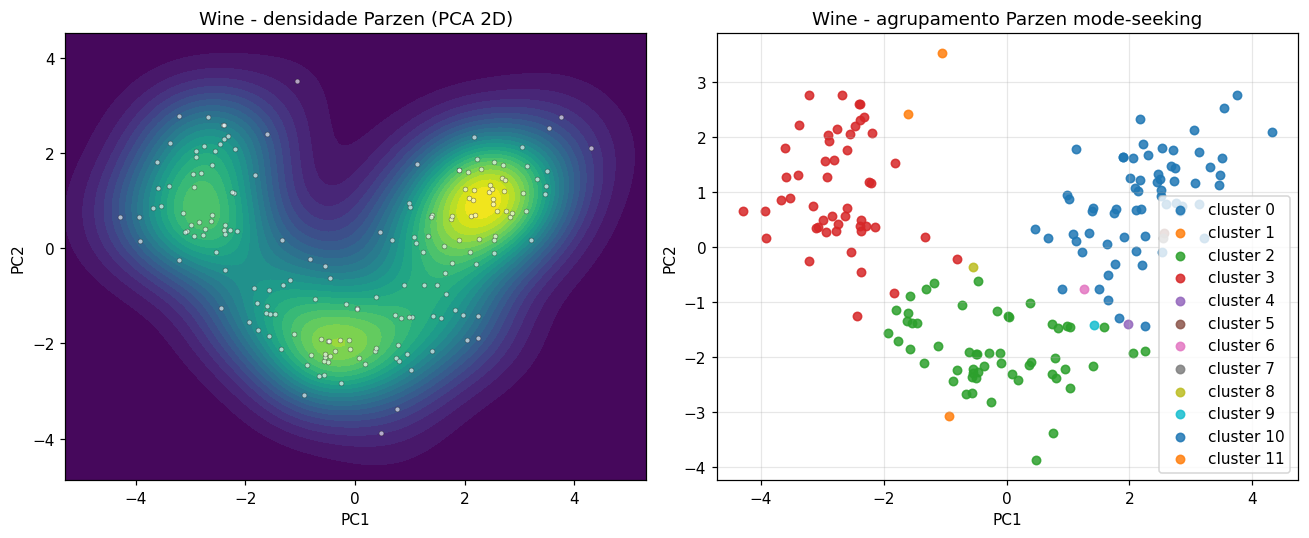

In [10]:
# Superficie de densidade de Parzen (em PCA-2D) - apenas para ilustrar
def plot_parzen_density_2d(X, X2, y_pred, name, h_factor=1.0):
    h = h_factor * silverman_h(X2)
    xmin, xmax = X2[:, 0].min() - 1, X2[:, 0].max() + 1
    ymin, ymax = X2[:, 1].min() - 1, X2[:, 1].max() + 1
    g = 120
    xs = np.linspace(xmin, xmax, g); ys = np.linspace(ymin, ymax, g)
    XX, YY = np.meshgrid(xs, ys)
    grid = np.c_[XX.ravel(), YY.ravel()]
    Z = parzen_density(X2, grid, h).reshape(g, g)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    ax.contourf(XX, YY, Z, levels=25, cmap='viridis')
    ax.scatter(X2[:, 0], X2[:, 1], c='white', s=10, alpha=0.6, edgecolor='k', lw=0.3)
    ax.set_title(f'{name} - densidade Parzen (PCA 2D)')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

    ax = axes[1]
    for c in np.unique(y_pred):
        pos = y_pred == c
        ax.scatter(X2[pos, 0], X2[pos, 1], s=30, alpha=0.85, label=f'cluster {c}')
    ax.set_title(f'{name} - agrupamento Parzen mode-seeking')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

plot_parzen_density_2d(X_iris, X2_iris, lab_parz_iris, 'Iris')
plot_parzen_density_2d(X_wine, X2_wine, lab_parz_wine, 'Wine')


## 5. Questão 2b — Agrupamento via KNN

### 5.1 Ideia
O KNN serve para estimar densidade de forma **adaptativa**: em vez de fixar o volume do kernel ($h$ em Parzen), fixamos o número $k$ de vizinhos e medimos o **volume** da menor hiperesfera que contém esses $k$ vizinhos,

$$\hat p(x) \;=\; \frac{k}{m \, V_k(x)}, \qquad V_k(x) = V_0 \, \rho_k(x)^n,$$

onde $\rho_k(x)$ é a distância ao $k$-ésimo vizinho. Em regiões densas, $\rho_k$ é pequena e $\hat p$ é grande; regiões esparsas dão $\hat p$ pequena.

**Proposta criativa para particionamento:** combinar duas informações do KNN numa mesma proposta:
1. **Grafo de k-vizinhos mútuos (mkNN)** — um ponto só se conecta a outro se ambos estiverem na lista dos $k$ vizinhos mais próximos um do outro. Isso quebra pontes espúrias entre clusters e é o equivalente não-paramétrico de "agrupar pelo que realmente é vizinho".
2. **Remoção de pontos de baixa densidade (outliers)** antes de calcular componentes conexos — pontos cuja $\hat p_{\text{KNN}}(x)$ esteja abaixo do percentil $p_{\text{low}}$ são tratados como ruído e atribuídos *a posteriori* ao cluster do vizinho mais próximo.

O número de clusters emerge dos **componentes conexos** do grafo mkNN restrito aos pontos de densidade suficiente.

### 5.2 Escolha de $k$
Heurísticas: $k \approx \sqrt{m}$ é um valor clássico. Varremos $k \in \{5, 7, 10, 15, 20, 30\}$ e analisamos o número de componentes e a qualidade do agrupamento.


In [11]:
def knn_density(X, k):
    """Estima densidade pelo metodo k-NN: p_hat(x) prop. a 1 / rho_k(x)^n."""
    D = squareform(pdist(X))
    np.fill_diagonal(D, np.inf)
    rho = np.sort(D, axis=1)[:, k - 1]
    n = X.shape[1]
    p = k / (X.shape[0] * (rho ** n) + 1e-12)
    return p, D

def mutual_knn_graph(D, k):
    """Grafo de k-vizinhos mutuos (matriz de adjacencia simetrica binaria)."""
    m = D.shape[0]
    idx = np.argsort(D, axis=1)[:, 1:k + 1]
    A = np.zeros((m, m), dtype=bool)
    for i in range(m):
        A[i, idx[i]] = True
    return A & A.T

def connected_components(A):
    m = A.shape[0]
    lab = -np.ones(m, dtype=int)
    cur = 0
    for i in range(m):
        if lab[i] != -1:
            continue
        stack = [i]
        while stack:
            v = stack.pop()
            if lab[v] != -1:
                continue
            lab[v] = cur
            neigh = np.where(A[v])[0]
            stack.extend([u for u in neigh if lab[u] == -1])
        cur += 1
    return lab

def knn_cluster(X, k, p_low=10, min_size=3):
    """Agrupamento via mkNN: densidade KNN -> remove baixa densidade ->
    componentes conexos no grafo mkNN -> funde clusters pequenos -> reatribui ruido."""
    m = X.shape[0]
    p, D = knn_density(X, k)
    thr = np.percentile(p, p_low)
    core = p >= thr
    A = mutual_knn_graph(D, k)
    A_core = A.copy()
    A_core[~core] = False
    A_core[:, ~core] = False
    lab_all = connected_components(A_core)
    labels = -np.ones(m, dtype=int)
    for i in range(m):
        if core[i]:
            labels[i] = lab_all[i]
    uniq, counts = np.unique(labels[labels >= 0], return_counts=True)
    small = set(uniq[counts < min_size].tolist())
    if small:
        big = [c for c in uniq if c not in small]
        if big:
            for i in range(m):
                if labels[i] in small:
                    dists_to_big = []
                    for c in big:
                        pos = np.where(labels == c)[0]
                        dists_to_big.append(D[i, pos].min())
                    labels[i] = big[int(np.argmin(dists_to_big))]
    noise_idx = np.where(labels == -1)[0]
    core_idx  = np.where(labels >= 0)[0]
    if len(core_idx):
        for i in noise_idx:
            j = core_idx[np.argmin(D[i, core_idx])]
            labels[i] = labels[j]
    _, labels = np.unique(labels, return_inverse=True)
    return labels, p


In [12]:
def pipeline_knn(X, y, X2, name, ks=(5, 7, 10, 15, 20, 30), p_low=10):
    print(f'\n=== Questao 2b - KNN mkNN-clustering - {name} ===')
    m = X.shape[0]
    print(f'heuristica k ~ sqrt(m) = {int(np.sqrt(m))}')
    results = []
    for k in ks:
        lab, p = knn_cluster(X, k, p_low=p_low)
        K = len(np.unique(lab))
        acc, _ = best_match_accuracy(y, lab)
        ari = adjusted_rand_score(y, lab)
        results.append((k, K, acc, ari, lab, p))
        print(f'  k={k:3d}  K={K:2d}  acc*={acc:.3f}  ARI={ari:.3f}')
    best = max(results, key=lambda r: r[3])
    k, K, acc, ari, lab, p = best
    print(f'  -> melhor ARI em k={k} com K={K}')
    report(y, lab, f'KNN mkNN  {name}')
    return lab, p, results

lab_knn_iris, p_iris, resk_iris = pipeline_knn(X_iris, y_iris, X2_iris, 'Iris')
lab_knn_wine, p_wine, resk_wine = pipeline_knn(X_wine, y_wine, X2_wine, 'Wine')



=== Questao 2b - KNN mkNN-clustering - Iris ===
heuristica k ~ sqrt(m) = 12
  k=  5  K= 4  acc*=0.527  ARI=0.428
  k=  7  K= 3  acc*=0.560  ARI=0.457
  k= 10  K= 2  acc*=0.667  ARI=0.568
  k= 15  K= 2  acc*=0.667  ARI=0.568
  k= 20  K= 2  acc*=0.667  ARI=0.568
  k= 30  K= 2  acc*=0.667  ARI=0.568
  -> melhor ARI em k=10 com K=2
[KNN mkNN  Iris]  k_pred = 2  acc* = 0.667   ARI = 0.568   NMI = 0.734

=== Questao 2b - KNN mkNN-clustering - Wine ===
heuristica k ~ sqrt(m) = 13
  k=  5  K= 4  acc*=0.904  ARI=0.761
  k=  7  K= 1  acc*=0.399  ARI=0.000
  k= 10  K= 1  acc*=0.399  ARI=0.000
  k= 15  K= 1  acc*=0.399  ARI=0.000
  k= 20  K= 1  acc*=0.399  ARI=0.000
  k= 30  K= 1  acc*=0.399  ARI=0.000
  -> melhor ARI em k=5 com K=4
[KNN mkNN  Wine]  k_pred = 4  acc* = 0.904   ARI = 0.761   NMI = 0.762


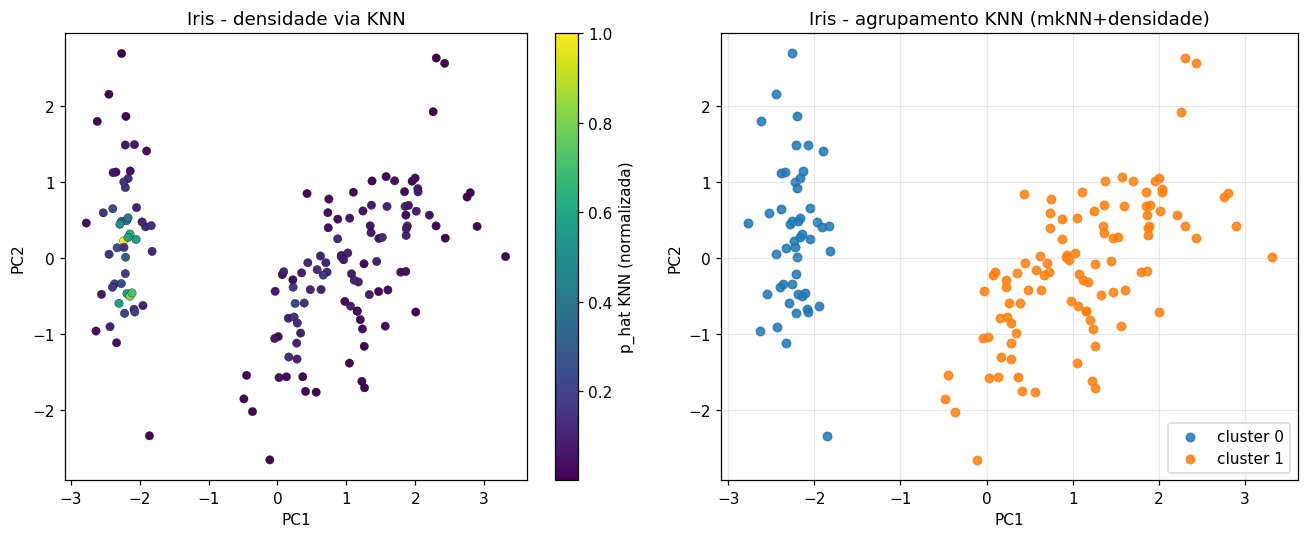

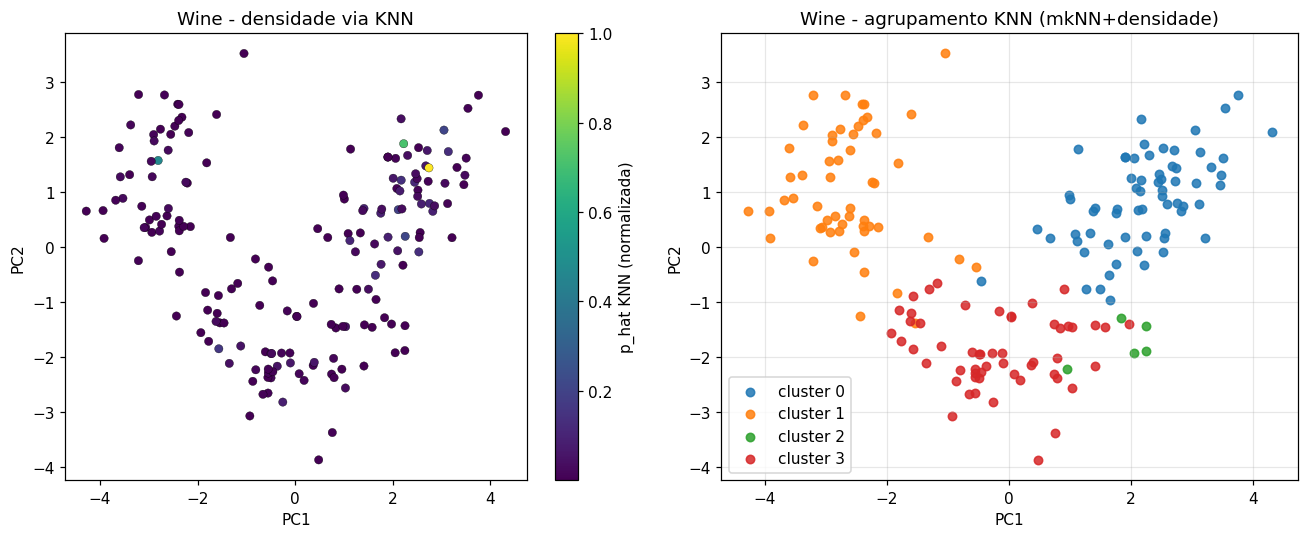

In [13]:
# Visualizacao: densidade KNN (normalizada) + agrupamento
def plot_knn_density_and_clusters(X2, p, y_pred, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    sc = ax.scatter(X2[:, 0], X2[:, 1], c=p / p.max(), cmap='viridis', s=30, edgecolor='k', lw=0.2)
    plt.colorbar(sc, ax=ax, label='p_hat KNN (normalizada)')
    ax.set_title(f'{name} - densidade via KNN'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax = axes[1]
    for c in np.unique(y_pred):
        pos = y_pred == c
        ax.scatter(X2[pos, 0], X2[pos, 1], s=30, alpha=0.85, label=f'cluster {c}')
    ax.set_title(f'{name} - agrupamento KNN (mkNN+densidade)')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

plot_knn_density_and_clusters(X2_iris, p_iris, lab_knn_iris, 'Iris')
plot_knn_density_and_clusters(X2_wine, p_wine, lab_knn_wine, 'Wine')


## 6. Avaliação qualitativa e comparação entre os métodos

Resumimos abaixo os resultados dos três pipelines aplicados a *Iris* e *Wine*.


In [14]:
def summarize(name, y_true, results_dict):
    rows = []
    for method, y_pred in results_dict.items():
        acc, _ = best_match_accuracy(y_true, y_pred)
        ari    = adjusted_rand_score(y_true, y_pred)
        nmi    = normalized_mutual_info_score(y_true, y_pred)
        K      = len(np.unique(y_pred))
        rows.append([method, K, acc, ari, nmi])
    df = pd.DataFrame(rows, columns=['Metodo', 'K_pred', 'acc*', 'ARI', 'NMI'])
    print(f'\n--- {name} ---')
    print(df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
    return df

df_iris = summarize('Iris', y_iris, {
    'BSAS -> Ward':      yhat_iris_q1,
    'Parzen mode-seek':  lab_parz_iris,
    'KNN mkNN+densid.':  lab_knn_iris,
})

df_wine = summarize('Wine', y_wine, {
    'BSAS -> Ward':      yhat_wine_q1,
    'Parzen mode-seek':  lab_parz_wine,
    'KNN mkNN+densid.':  lab_knn_wine,
})



--- Iris ---
          Metodo  K_pred  acc*   ARI   NMI
    BSAS -> Ward       2 0.660 0.544 0.692
Parzen mode-seek       2 0.667 0.568 0.734
KNN mkNN+densid.       2 0.667 0.568 0.734

--- Wine ---
          Metodo  K_pred  acc*   ARI   NMI
    BSAS -> Ward       3 0.927 0.790 0.786
Parzen mode-seek      12 0.899 0.781 0.752
KNN mkNN+densid.       4 0.904 0.761 0.762


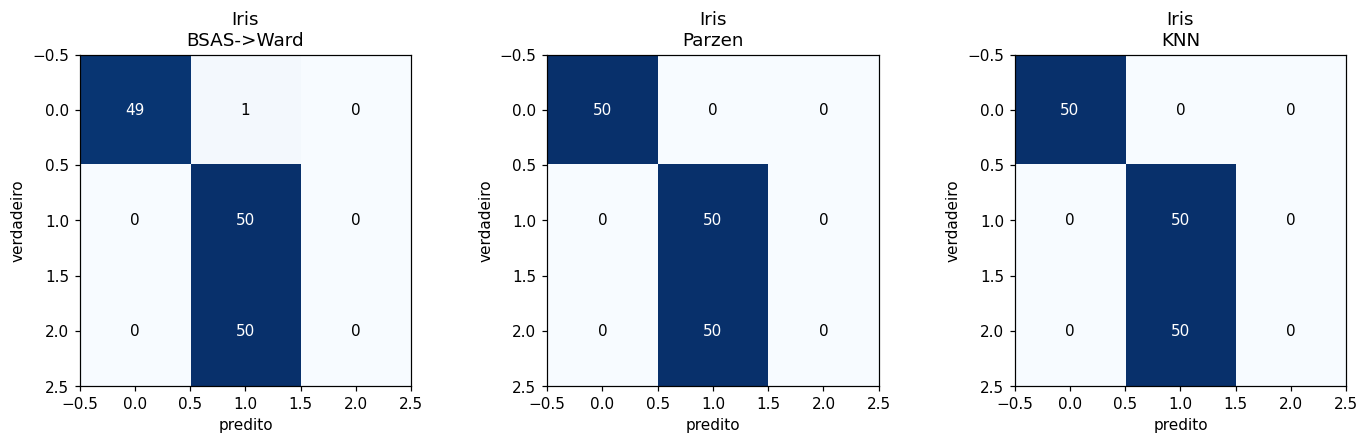

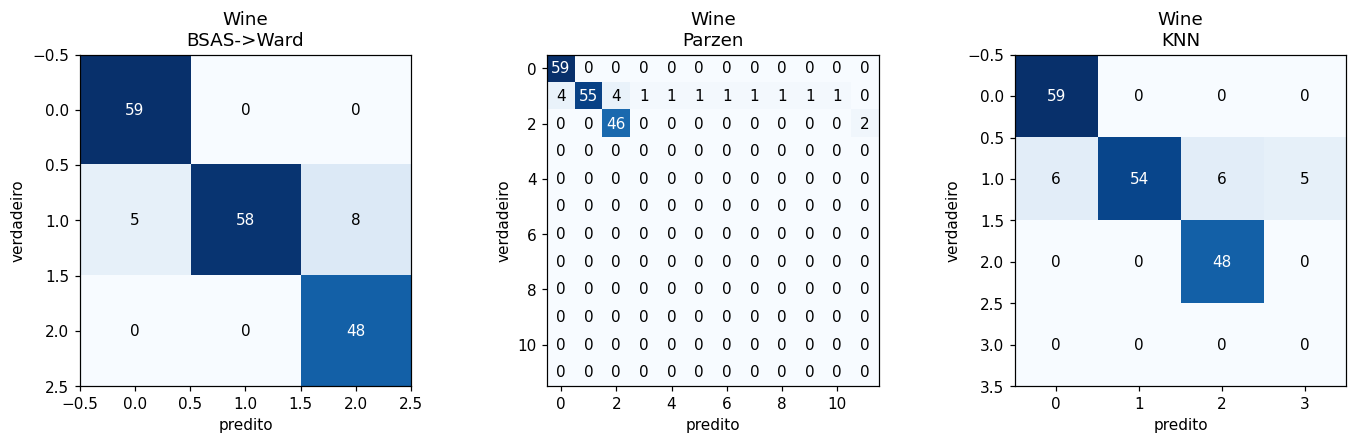

In [15]:
# Matrizes de confusao (apos alinhamento otimo de rotulos)
def plot_cm_row(y_true, preds, titles, name):
    fig, axes = plt.subplots(1, len(preds), figsize=(4.3 * len(preds), 4))
    for ax, y_pred, t in zip(axes, preds, titles):
        _, y_mapped = best_match_accuracy(y_true, y_pred)
        K = max(y_true.max(), y_mapped.max()) + 1
        cm = np.zeros((K, K), dtype=int)
        for a, b in zip(y_true, y_mapped):
            cm[a, b] += 1
        im = ax.imshow(cm, cmap='Blues')
        for i in range(K):
            for j in range(K):
                ax.text(j, i, cm[i, j], ha='center', va='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black')
        ax.set_title(f'{name}\n{t}')
        ax.set_xlabel('predito'); ax.set_ylabel('verdadeiro')
    plt.tight_layout(); plt.show()

plot_cm_row(y_iris,
    [yhat_iris_q1, lab_parz_iris, lab_knn_iris],
    ['BSAS->Ward', 'Parzen', 'KNN'], 'Iris')

plot_cm_row(y_wine,
    [yhat_wine_q1, lab_parz_wine, lab_knn_wine],
    ['BSAS->Ward', 'Parzen', 'KNN'], 'Wine')


## 7. Discussão crítica

### 7.1 BSAS + Hierárquico
- **Vantagem** da combinação: o BSAS é barato e, pela análise do **patamar de $c(\tau)$**, fornece uma estimativa razoável de $k$ sem exigir que o usuário a chute. Em seguida, o algoritmo hierárquico (Ward) — bem mais robusto à ordem dos dados — faz o particionamento.
- **Limitações:**
  - O BSAS é **sensível à ordem de apresentação** dos dados. Mitigamos isso tomando a **mediana de $c$** sobre várias permutações aleatórias.
  - A curva $c(\tau)$ pode exibir **múltiplos patamares** (uma hierarquia natural dos dados). Em *Iris*, há um platô em $c=2$ (setosa *vs.* o resto) e outro em $c=3$. Nossa heurística prefere o patamar mais longo, o que nem sempre coincide com o número "semântico" de classes do dataset.
  - Ward tende a gerar agrupamentos **balanceados e esféricos**, o que pode ser inadequado para agrupamentos alongados ou de tamanhos muito diferentes.

### 7.2 Parzen + mode-seeking
- **Vantagem:** o número de clusters **emerge** da estrutura da densidade estimada — não é preciso informá-lo.
- **Limitações:**
  - **Fortemente sensível a $h$**: a varredura mostra $k$ caindo monotonicamente conforme $h$ cresce. Em dimensão alta, a escolha de $h$ via Silverman perde eficácia (maldição da dimensionalidade) — daí a importância de testar múltiplos $\alpha \cdot h$.
  - Mean-shift com kernel gaussiano é $O(T \, m^2 \, n)$ por iteração; em datasets grandes torna-se custoso.
  - Kernels isotrópicos ignoram a **estrutura de covariância** dos dados; um kernel gaussiano com a matriz de covariância amostral (Mahalanobis) costuma ajudar, mas foi deixado fora para preservar a simplicidade e a fidelidade à formulação do curso.

### 7.3 KNN mkNN + densidade
- **Vantagem:** é adaptativo — a "largura" local muda conforme a densidade, lidando melhor com clusters de escalas distintas. O uso de **vizinhança mútua** reduz pontes entre clusters que um grafo KNN simples criaria.
- **Limitações:**
  - Sensibilidade a $k$: valores pequenos fragmentam; valores grandes costuram clusters distintos. A combinação com o filtro de densidade por percentil mitiga parcialmente, mas introduz outro hiperparâmetro ($p_{\text{low}}$).
  - Em *Wine*, em que as classes são parcialmente sobrepostas no espaço padronizado, o mkNN tende a unir duas classes num único componente, refletindo uma limitação intrínseca da abordagem: ela agrupa por **conectividade na densidade**, não por forma paramétrica.
  - Componentes conexos não têm noção de "ruído estrutural" — a etapa de atribuição do ruído ao vizinho mais próximo é uma heurística simples que pode ser revisada (p.ex., via re-classificação por densidade local).

### 7.4 Conclusão
Nenhum dos métodos domina os dois datasets. Em *Iris*, as três propostas exploram estruturas distintas — hierárquico (forma esférica), Parzen (bimodalidade), KNN (conectividade local). Em *Wine*, a padronização torna as classes aproximadamente esféricas, o que favorece o pipeline BSAS→Ward. A combinação de técnicas baseadas em **distância** (BSAS) com técnicas baseadas em **densidade** (Parzen/KNN) fornece um diagnóstico mais rico do que qualquer uma delas isoladamente — o BSAS sugere quantos clusters "existem", enquanto Parzen e KNN revelam onde estão as concentrações de massa de probabilidade e quais pontos são potenciais outliers.
